In [1]:
import os
import numpy as np
import pandas as pd
import mne
from pathlib import Path
import logging
from collections import defaultdict
import matplotlib
#matplotlib.use('Qt5Agg')

In [2]:
# == Configuration ==
# === Logging format: timestamp - level - message ===
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# === Paths ===
CURRENT_DIR = Path.cwd()
PATH_DATA_RAW = CURRENT_DIR.parent / "01_Data" / "raw"

# === Subject lists ===
SUBJECT_IDS = [f'sub-{i}' for i in [
    1117, 1118, 1120, 
    #1124, 1126, 1131, 1132, 1135, 1136,
    #1151, 1160, 1164, 1167, 1169, 1172, 1173, 1178,
    #1182, 1215, 1216, 1219, 1223, 1227, 1233,
    #1234, 1237, 1240, 1243, 1245, 1247, 1250, 1239,
    #1252, 1257, 1261, 1265, 1266, 1268, 1270, 1276, 1281
    ]]

# === BIDS labels ===
BIDS_TASK_LABEL_EEG = '_task-dynamic'
BIDS_EEG_SUFFIX = '_eeg'
BIDS_TASK_LABEL_BEH = '_task-MAT'
BIDS_BEH_SUFFIX = '_behavEEG'

# === ERP parameters ===
ERP_TMIN, ERP_TMAX = -0.5, 2
RESP_PRE, RESP_POST = -1, 0.2
BASELINE_TMIN, BASELINE_TMAX = -0.25, 0


In [4]:
# === Test ===
PATH_PREPROCESS_DATA_BIDS = CURRENT_DIR.parent / '01_Data' / 'preprocess' 
beh_files = sorted(PATH_PREPROCESS_DATA_BIDS.glob('sub-*/beh/*_beh.csv'))
eeg_files = sorted(PATH_PREPROCESS_DATA_BIDS.glob('sub-*/eeg/*.vhdr'))
beh_by_sub = {p.parent.parent.name: p for p in beh_files}
eeg_by_sub = {p.parent.parent.name: p for p in eeg_files}

for sub_id in SUBJECT_IDS:
    path_eeg = eeg_by_sub[f'{sub_id}']
    path_behavior = beh_by_sub[f'{sub_id}']
    logger.info(f"Processing subject: {sub_id}")

    # === Step 1: load eeg and behavior data ===
    data_behavior = pd.read_csv(path_behavior)
    if 'probe_rt' not in data_behavior.columns:
        logger.warning(f"{sub_id}: rt column missing in behavior, skipping")
        continue
    index_valid_trial = data_behavior[data_behavior['rt_is_not_outlier']].index.to_list()

    raw = mne.io.read_raw_brainvision(path_eeg, preload=True, verbose='ERROR')
    events, event_id = mne.events_from_annotations(raw, verbose='ERROR')

    raw.set_channel_types({
        'VEOG': 'eog',
        'HEOGL': 'eog',
        'HEOGR': 'eog',
        'ECG': 'ecg',
        })  
    
    montage = mne.channels.make_standard_montage('standard_1005')
    raw.set_montage(montage, match_case=False, on_missing='ignore')

    stim_event_id = {"Stimulus/S  8": 8}
    stim_value =8
    stim_events = events[events[:,2]==stim_value]

    assert len(stim_events) == len(data_behavior), f"{sub_id}: events and data_behavior have different lengths"
    print(f'raw length of data:{len(data_behavior)}')

    # === Step 2: Epoch data ===
    epochs_full = mne.Epochs(
        raw,
        events = stim_events,
        event_id = stim_event_id,
        tmin = ERP_TMIN,
        tmax = ERP_TMAX,
        baseline= (BASELINE_TMIN, BASELINE_TMAX),
        #reject_by_annotation=True,
        #reject = {"eeg": 200e-5},
        metadata = data_behavior,
        preload = True,
        event_repeated = 'drop',
        verbose='ERROR',
    )

    beh_clean = epochs_full.metadata.reset_index(drop=True)
    print(f'clean beh data:{len(beh_clean)}; epoch data:{len(epochs_full)}')

# test length
epochs_conditions = len(epochs_full["cue_dimensionality == 4"])
behavior_conditions = len(data_behavior[data_behavior['cue_dimensionality'] == 4])
print(f'epochs_conditions: {epochs_conditions}; behavior_condition: {behavior_conditions}')

2026-06-13 13:34:18,405 - INFO - Processing subject: sub-1117
/var/folders/xc/16fqwx1n1gbfb77yd1bdg8mh0000gn/T/ipykernel_63332/1974650099.py:31: RuntimeWarning: Not setting position of 1 misc channel found in montage:
['A1']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(montage, match_case=False, on_missing='ignore')
2026-06-13 13:34:20,433 - INFO - Processing subject: sub-1118


raw length of data:256
clean beh data:256; epoch data:256


/var/folders/xc/16fqwx1n1gbfb77yd1bdg8mh0000gn/T/ipykernel_63332/1974650099.py:31: RuntimeWarning: Not setting position of 1 misc channel found in montage:
['A1']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(montage, match_case=False, on_missing='ignore')
2026-06-13 13:34:21,564 - INFO - Processing subject: sub-1120


raw length of data:256
clean beh data:256; epoch data:256
raw length of data:256
clean beh data:256; epoch data:256
epochs_conditions: 64; behavior_condition: 64


/var/folders/xc/16fqwx1n1gbfb77yd1bdg8mh0000gn/T/ipykernel_63332/1974650099.py:31: RuntimeWarning: Not setting position of 1 misc channel found in montage:
['A1']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(montage, match_case=False, on_missing='ignore')


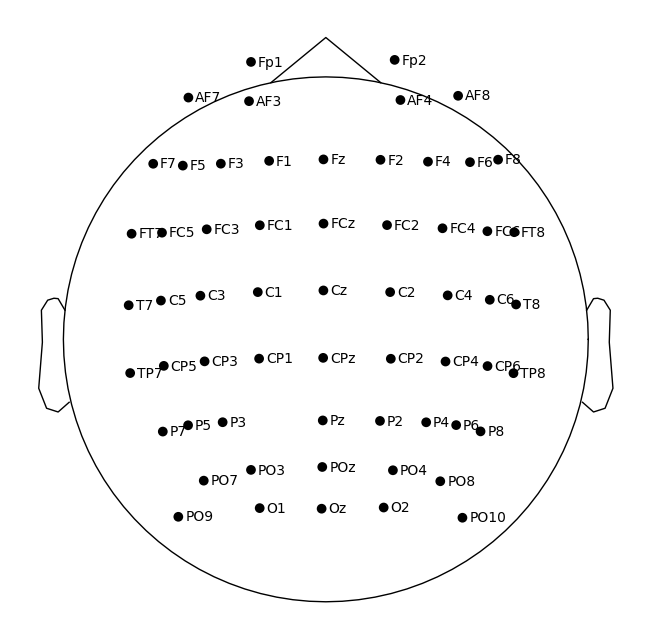

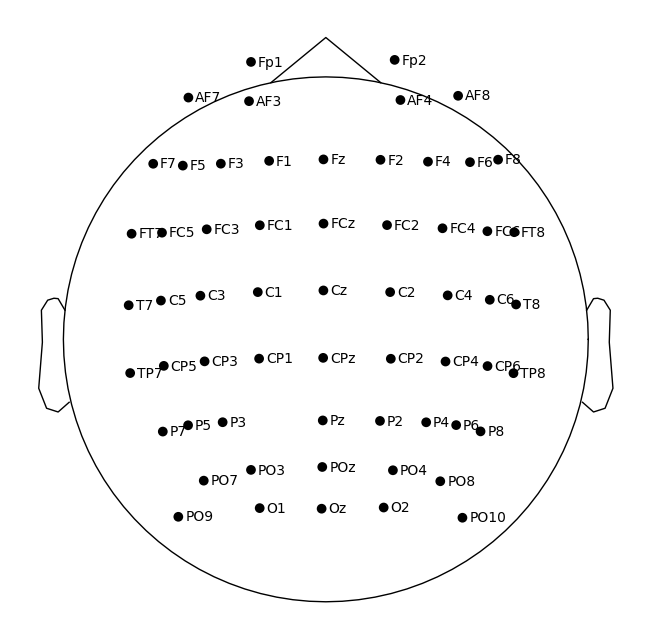

In [5]:
raw.plot_sensors(kind='topomap', show_names=True)

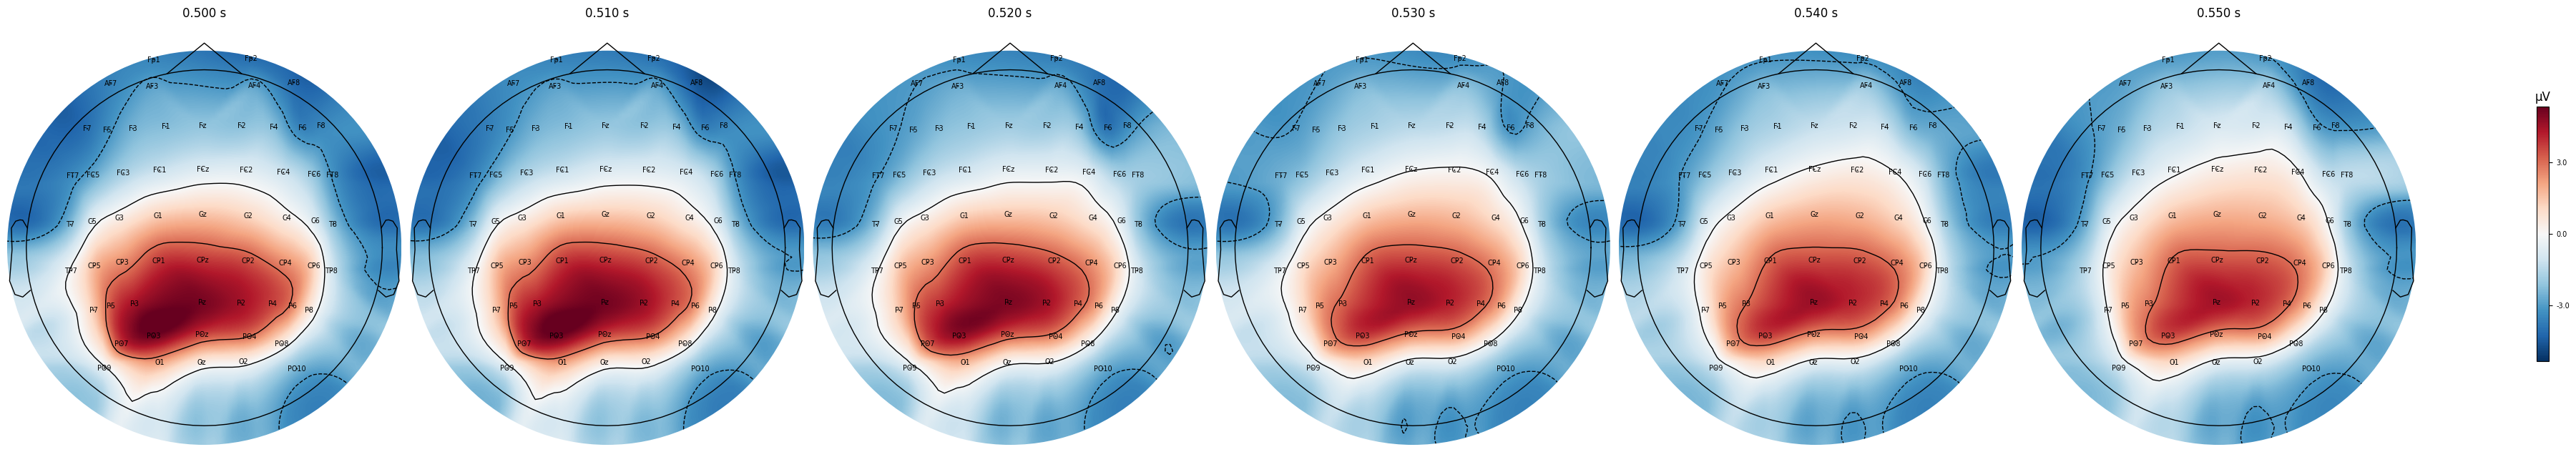

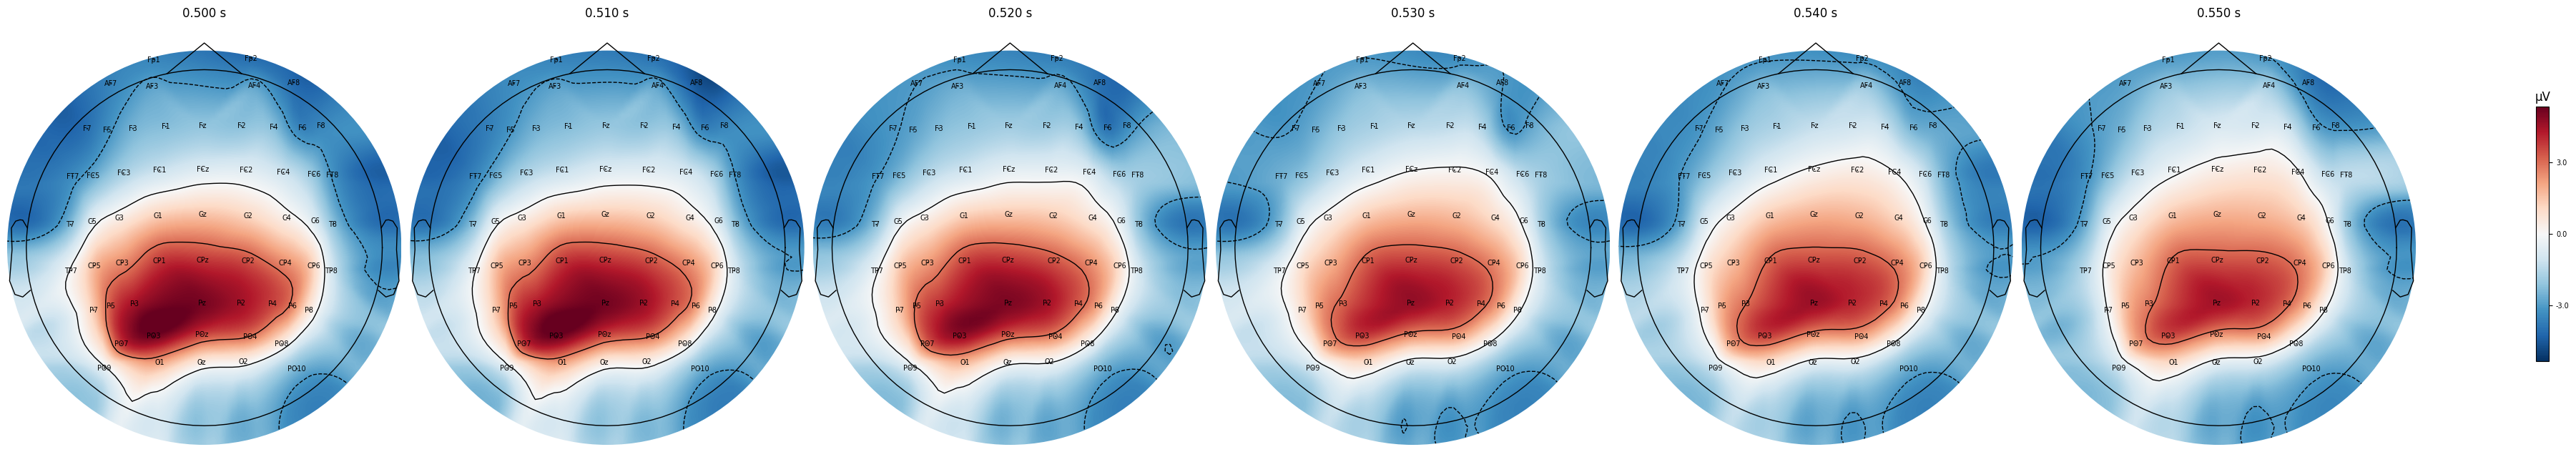

In [6]:
evoked = epochs_full.average()

# plot ERP topomap
evoked.plot_topomap(
    times=[0.5, 0.51,0.52,0.53, 0.54,0.55],
    ch_type='eeg',
    sensors=True,
    show_names=True,
    size=4,
    contours=3,
)